# Importación de librerias



In [1]:
# !pip install pycbc lalsuite # Para generación de señales físicas reales
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from scipy import signal

#  Generación de la señal física

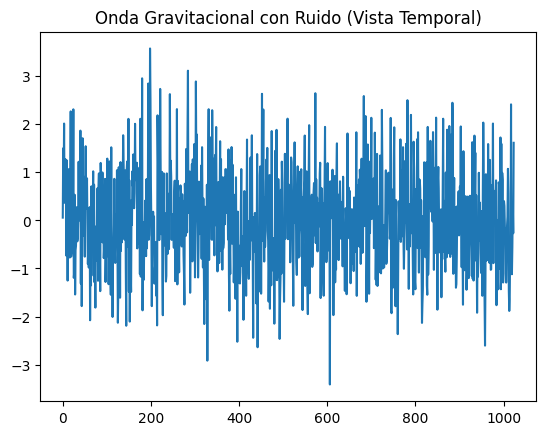

In [2]:
def generate_signal(snr_level=10):
    # Parámetros temporales
    t = np.linspace(0, 1, 1024)

    # Creamos un "chirp" (fusión de dos masas)
    # La frecuencia aumenta de 20Hz a 500Hz
    wav = signal.chirp(t, f0=20, f1=500, t1=1, method="quadratic")

    # Añadimos ruido blanco (simulando el ruido del detector)
    noise = np.random.normal(0, 1, len(t))

    # Ajustamos la amplitud de la señal según el SNR (Relación Señal-Ruido)
    # SNR = Amplitud_Señal / Amplitud_Ruido
    amplitude = snr_level / np.sqrt(len(t))
    return (wav * amplitude) + noise


# Visualización
plt.plot(generate_signal(snr_level=15))
plt.title("Onda Gravitacional con Ruido (Vista Temporal)")
plt.show()

# Procesamiento (Espectrograma)

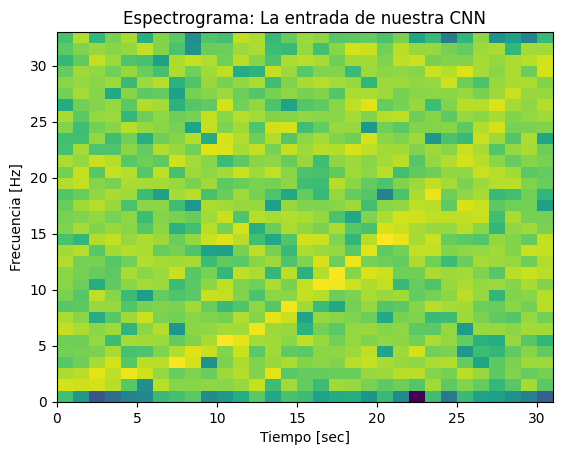

In [3]:
def get_spectrogram(data):
    # nperseg=64 obliga a tener más divisiones temporales
    f, t, Sxx = signal.spectrogram(data, fs=1024, nperseg=64, noverlap=32)
    return np.log(Sxx + 1e-10)

    # Vamos a imprimir la forma la primera vez para estar seguros
    # print(f"Forma del espectrograma: {Sxx.shape}")

    return np.log(Sxx + 1e-10)  # para resaltar la señal


# Ejemplo de lo que "verá" la CNN
sample_spec = get_spectrogram(generate_signal(snr_level=20))
plt.pcolormesh(sample_spec)
plt.ylabel("Frecuencia [Hz]")
plt.xlabel("Tiempo [sec]")
plt.title("Espectrograma: La entrada de nuestra CNN")
plt.show()

# Arquitectura CNN 

In [ ]:
from tensorflow.keras import layers, models


def build_model(input_shape):
    model = models.Sequential(
        [
            layers.Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(64, (3, 3), activation="relu"),
            layers.MaxPooling2D((2, 2)),
            layers.Conv2D(128, (3, 3), activation="relu"),
            layers.Flatten(),
            layers.Dense(64, activation="relu"),
            layers.Dropout(
                0.7
            ),  # 70% de las neuronas se apagan aleatoriamente en cada paso
            layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


# Cálculo de la forma
test_sig = generate_signal()
test_spec = get_spectrogram(test_sig)
# Esto detectará automáticamente el tamaño (ej. 33, 61, 1)
shape_real = (test_spec.shape[0], test_spec.shape[1], 1)

model = build_model(shape_real)
model.summary()

#  Creación del Dataset 

In [ ]:
# Definimos cuántas muestras queremos
num_muestras = 10000
X, y = [], []
for i in range(10000):
    has_signal = np.random.choice([0, 1])
    # Señales más claras para que la red pueda aprender mejor
    snr_random = np.random.uniform(10, 25)
    raw_data = generate_signal(snr_level=snr_random if has_signal else 0)

    # Convertimos a espectrograma
    spec = get_spectrogram(raw_data)

    X.append(spec)
    y.append(has_signal)

# Convertimos a arrays de numpy y ajustamos dimensiones
X = np.array(X)
y = np.array(y)

# IMPORTANTE: La CNN espera 4 dimensiones (muestras, ancho, alto, canales)
# Como es blanco y negro, añadimos 1 canal al final
X = X[..., np.newaxis]

print(f"Dataset listo: {X.shape[0]} imágenes de {X.shape[1]}x{X.shape[2]}")

#  Entrenamiento 

In [ ]:
# Entrenamiento Optimizado
from tensorflow.keras import optimizers

# Usamos un Learning Rate más pequeño (0.0001 en lugar del 0.001 por defecto)
# Esto hará que las curvas sean mucho más suaves y estables
opt = optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    epochs=50,  # Con un learning rate bajo, necesitamos más épocas para llegar al óptimo
    batch_size=64,  # Aumentar el batch_size también ayuda a estabilizar
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
)

#  Visualización de Curvas de Aprendizaje

In [ ]:
import matplotlib.pyplot as plt

# Graficamos la precisión (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")
plt.title("Precisión del Modelo")
plt.xlabel("Época")
plt.ylabel("Precisión")
plt.legend()

# Graficamos la pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")
plt.title("Pérdida (Error) del Modelo")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

#  Evaluación con Curva ROC

In [ ]:
from sklearn.metrics import roc_curve, auc

# Predecimos sobre el set de test
y_pred_keras = model.predict(X_test).ravel()
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test, y_pred_keras)
auc_keras = auc(fpr_keras, tpr_keras)

plt.figure(1)
plt.plot([0, 1], [0, 1], "k--")
plt.plot(fpr_keras, tpr_keras, label="CNN (area = {:.3f})".format(auc_keras))
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC - Detección de Ondas")
plt.legend(loc="best")
plt.show()

# Test de Sensibilidad por SNR

In [ ]:
def evaluar_snr_especifico(model, snr_target):
    # Generamos 200 muestras nuevas con un SNR fijo
    X_snr = []
    y_snr = []
    for _ in range(200):
        has_sig = np.random.choice([0, 1])
        raw = generate_signal(snr_level=snr_target if has_sig else 0)
        X_snr.append(get_spectrogram(raw))
        y_snr.append(has_sig)

    X_snr = np.array(X_snr)[..., np.newaxis]
    loss, acc = model.evaluate(X_snr, np.array(y_snr), verbose=0)
    return acc


# Probamos con diferentes niveles de dificultad
niveles_snr = [2, 4, 6, 8, 10, 15, 20]
precisiones = [evaluar_snr_especifico(model, s) for s in niveles_snr]

plt.figure()
plt.plot(niveles_snr, precisiones, "o-")
plt.axhline(y=0.5, color="r", linestyle="--", label="Azar (50%)")
plt.xlabel("SNR (Relación Señal-Ruido)")
plt.ylabel("Precisión (Accuracy)")
plt.title("Capacidad de detección según la intensidad de la señal")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Definimos los niveles de SNR que queremos testear 
niveles_snr = [2, 4, 6, 8, 10, 15, 20]

print("Evaluando sensibilidad del modelo por niveles de SNR...")
precisiones = []

for s in niveles_snr:
    acc = evaluar_snr_especifico(model, s)
    precisiones.append(acc)
    print(f"Precisión para SNR {s}: {acc * 100:.1f}%")

# Creamos la gráfica de rendimiento
plt.figure(figsize=(8, 5))
plt.plot(niveles_snr, precisiones, marker="o", linestyle="-", color="b", linewidth=2)
plt.axhline(y=0.5, color="r", linestyle="--", label="Límite del Azar (50%)")
plt.title("Sensibilidad del Detector: Precisión vs SNR", fontsize=14)
plt.xlabel("Relación Señal-Ruido (SNR)", fontsize=12)
plt.ylabel("Exactitud (Accuracy)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

#  Test de Generalización

In [ ]:
def test_generalization(model):
    t = np.linspace(0, 1, 1024)
    # Creamos un chirp LINEAL en lugar de cuadrático (algo que la red no vio)
    sig_lineal = signal.chirp(t, f0=50, f1=250, t1=1, method="linear")
    snr = 15
    data = np.random.normal(0, 1, len(t)) + (sig_lineal * (snr / np.sqrt(len(t))))

    spec = get_spectrogram(data)[np.newaxis, ..., np.newaxis]
    pred = model.predict(spec)

    print(f"Probabilidad de ser onda (Chirp Lineal): {pred[0][0]:.4f}")


test_generalization(model)

In [ ]:
print("Ejecutando test de generalización...")

# Probamos con una señal que la red SÍ conoce (Cuadrática)
print("\n--- Test con señal conocida (Cuadrática) ---")
test_generalization(model)  # Esta función usa por defecto la lógica conocida

# Creamos un test manual con una señal que la red NO ha visto (Chirp Lineal)
print("\n--- Test con señal nueva (Chirp Lineal) ---")
t_gen = np.linspace(0, 1, 1024)
# Generamos un Chirp Lineal (la red entrenó con Quadratic)
sig_lineal = signal.chirp(t_gen, f0=40, f1=200, t1=1, method="linear")
snr_test = 12
data_gen = np.random.normal(0, 1, len(t_gen)) + (
    sig_lineal * (snr_test / np.sqrt(len(t_gen)))
)

# Preprocesamos y predecimos
spec_gen = get_spectrogram(data_gen)[np.newaxis, ..., np.newaxis]
prob = model.predict(spec_gen, verbose=0)

print(
    f"Resultado: La red detecta la nueva onda con una probabilidad del {prob[0][0] * 100:.2f}%"
)
if prob[0][0] > 0.5:
    print("Conclusión: El modelo GENERALIZA correctamente a nuevas morfologías.")
else:
    print(
        "Conclusión: El modelo NO generaliza; es dependiente de la forma de entrenamiento."
    )

#  Comparativa Visual (Generalización)

In [ ]:
import matplotlib.pyplot as plt


def comparar_morfologias():
    t = np.linspace(0, 1, 1024)

    # Señal Cuadrática (La que la red conoce)
    sig_quad = signal.chirp(t, f0=50, f1=250, t1=1, method="quadratic")
    # Señal Lineal (La que la red NO conoce)
    sig_lin = signal.chirp(t, f0=50, f1=250, t1=1, method="linear")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Espectrograma Cuadrático
    f_q, t_q, Sxx_q = signal.spectrogram(sig_quad, fs=1024)
    ax1.pcolormesh(t_q, f_q, np.log(Sxx_q + 1e-10), shading="gouraud", cmap="magma")
    ax1.set_title("Morfología Conocida\n(Chirp Cuadrático)", fontsize=14)
    ax1.set_ylabel("Frecuencia [Hz]")
    ax1.set_xlabel("Tiempo [s]")

    # Espectrograma Lineal
    f_l, t_l, Sxx_l = signal.spectrogram(sig_lin, fs=1024)
    ax2.pcolormesh(t_l, f_l, np.log(Sxx_l + 1e-10), shading="gouraud", cmap="magma")
    ax2.set_title("Morfología Nueva\n(Chirp Lineal)", fontsize=14)
    ax2.set_ylabel("Frecuencia [Hz]")
    ax2.set_xlabel("Tiempo [s]")

    plt.tight_layout()
    plt.show()


comparar_morfologias()